# Lens-shaped InAs quantum dot in GaAs

First non-spherical dot shape: a **flat-bottomed circular lens** (half-ellipsoid dome) --
the classic self-assembled InAs/GaAs geometry. The base is a circle of radius `base_radius`
in the x-y plane and the dome rises to `height` on the z axis, so the **lateral (x,y) and
vertical (z) sizes are set independently**. The matrix (GaAs) surrounds the lens on all
sides -- barrier below the flat base and capping layer above, i.e. a lens sandwiched between
two barriers. (Real Stranski-Krastanov dots also sit on a thin InAs wetting layer, omitted
here; easy to add later as a thin slab joined to the base.)

**Why the strain treatment carries over to non-spherical shapes** -- this is not a hand-wave:
Davies, *J. Appl. Phys.* **84**, 1358 (1998) ("a simple picture") shows that in homogeneous
isotropic elasticity with a purely dilatational eigenstrain, the elastic field of *any*
inclusion is a superposition of point centers of dilatation, so **Tr(strain) is exactly
proportional to the dot's characteristic function**: uniform inside (same value as the
Eshelby sphere), exactly zero outside, for any shape. Since our single-band model only uses
Tr(strain) (hydrostatic deformation potentials), the sphere machinery applies to the lens
unchanged via `qdsolver_core.trace_strain_from_mask`. What would *not* carry over is the
shear/biaxial strain a multiband (Bir-Pikus) treatment needs -- that is genuinely
shape-dependent.

Other inherited caveats: single parabolic band per carrier; hard-mask voxelization (the
staircased lens boundary underestimates the analytic volume by ~13% at h=0.8 nm -- checked
below; reduce `h` if that matters for your comparison); hydrostatic-only strain.

In [8]:
import sys, os, time
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import qdsolver_core as qd

## Structure parameters -- edit these and re-run

A note on choosing the dimensions, from a quick sensitivity scan with this exact solver: in
our parameterization the strain-shifted conduction-band well is shallow (~125 meV), so the
**electron binding is very sensitive to the lens height** (light InAs mass, strong z
quantization): base 8 nm / height 4 nm left the electron only 0.8 meV below the GaAs barrier
(essentially unbound); 10/5 nm gives 16.4 meV; 10/7 nm gives 30.7 meV. The hole is deeply
bound (couple hundred meV) in all cases. Default below is 10/5.

In [9]:
matrix_mat, dot_mat = qd.MATERIALS['GaAs'], qd.MATERIALS['InAs']

base_radius = 10.0   # lateral (x,y) radius of the circular base (nm)
height = 5.0         # vertical (z) height of the dome (nm)
h = 0.8              # grid spacing (nm)
pad_xy = 8.0         # matrix padding beyond the base edge, laterally (nm)
pad_z = 8.0          # matrix padding below the base and above the apex (nm)

# Non-cubic box: lateral extent set by base_radius, vertical by height. The solver machinery
# is shape-generic (operators are built from the field arrays' own shape), so nothing else
# needs to change for a non-cubic grid.
cx = np.arange(-(base_radius + pad_xy), (base_radius + pad_xy) + 1e-9, h)
cz = np.arange(-pad_z, height + pad_z + 1e-9, h)
X, Y, Z = np.meshgrid(cx, cx, cz, indexing='ij')
print(f"grid {X.shape} = {X.size:,} points")

grid (46, 46, 27) = 57,132 points


## Geometry + volume sanity check

The analytic volume of a half-ellipsoid dome is $\tfrac{2}{3}\pi R^2 H$; the voxelized mask
should approach it as $h \to 0$ (the deficit at finite $h$ is the staircasing effect already
characterized in the convergence notebook).

In [10]:
inside = qd.lens_mask(X, Y, Z, base_radius, height)

vol_numeric = inside.sum() * h**3
vol_analytic = (2.0 / 3.0) * np.pi * base_radius**2 * height
print(f"voxel volume {vol_numeric:.1f} nm^3 vs analytic {vol_analytic:.1f} nm^3 "
      f"(ratio {vol_numeric/vol_analytic:.3f})")

voxel volume 907.3 nm^3 vs analytic 1047.2 nm^3 (ratio 0.866)


## Strain and material fields

`trace_strain_from_mask` applies the Davies characteristic-function result (see the header
cell and its docstring): Tr(strain) uniform inside the lens with the Eshelby-sphere value,
exactly zero outside -- valid for this arbitrary shape *because* we only need the
hydrostatic part.

In [11]:
eps_star = qd.eigenstrain(dot_mat['a0'], matrix_mat['a0'])
nu = qd.voigt_poisson_ratio(matrix_mat['C11'], matrix_mat['C12'], matrix_mat['C44'])
trace_strain, trace_inside = qd.trace_strain_from_mask(inside, eps_star, nu)

m_e_field = np.where(inside, dot_mat['m_e'], matrix_mat['m_e'])
m_h_field = np.where(inside, dot_mat['m_h'], matrix_mat['m_h'])
V_e = np.where(inside, dot_mat['fi_e'], matrix_mat['fi_e']) + dot_mat['Ac'] * trace_strain
V_h = np.where(inside, dot_mat['fi_h'], matrix_mat['fi_h']) + dot_mat['Av'] * trace_strain

print(f"lattice mismatch {eps_star*100:.2f}%, Tr(strain) inside = {trace_inside:.4f}")
print(f"electron well: dot floor {(dot_mat['fi_e']+dot_mat['Ac']*trace_inside)*1e3:.1f} meV, "
      f"GaAs barrier {matrix_mat['fi_e']*1e3:.1f} meV")
print(f"hole well:     dot ceiling {(dot_mat['fi_h']+dot_mat['Av']*trace_inside)*1e3:.1f} meV, "
      f"GaAs barrier {matrix_mat['fi_h']*1e3:.1f} meV")

lattice mismatch -6.69%, Tr(strain) inside = -0.1078
electron well: dot floor 799.8 meV, GaAs barrier 924.5 meV
hole well:     dot ceiling -255.8 meV, GaAs barrier -497.8 meV


## Solve, with two physics checks

1. **Circular-symmetry degeneracy**: the lens is rotationally symmetric about z, so the first
   excited states should come as a degenerate $p_x/p_y$ pair. On this Cartesian grid the
   x-y symmetry is represented exactly, so the degeneracy should hold to solver precision --
   a strong check that geometry and operators are wired correctly.
2. **Binding check**: is each state actually below its barrier (a real confined state), or a
   box-quantized continuum state?

In [12]:
t0 = time.time()
E_e, psi_e = qd.solve_states(m_e_field, V_e, h, n_states=4, hole=False)
E_h, psi_h = qd.solve_states(m_h_field, V_h, h, n_states=4, hole=True)
print(f"solved in {time.time()-t0:.1f} s")

print(f"\nE_e (meV): {np.round(E_e*1e3, 2)}")
print(f"E_h (meV): {np.round(E_h*1e3, 2)}")

print(f"\nelectron ground state bound by {(matrix_mat['fi_e']-E_e[0])*1e3:.1f} meV below the GaAs barrier")
print(f"electron p_x/p_y splitting: {(E_e[2]-E_e[1])*1e3:.4f} meV (should be ~0 by symmetry)")
print(f"hole p_x/p_y splitting:     {abs(E_h[2]-E_h[1])*1e3:.4f} meV (should be ~0 by symmetry)")

transition = E_e[0] - E_h[0]
print(f"\nnaive transition energy: {transition*1e3:.1f} meV ({1239.84/transition:.0f} nm)")
print("(naive = no electron-hole Coulomb attraction; plug these fields into")
print(" schrodinger_poisson.self_consistent_exciton for the corrected value)")

solved in 17.0 s

E_e (meV): [908.05 945.99 945.99 966.99]
E_h (meV): [-290.14 -302.79 -302.79 -316.69]

electron ground state bound by 16.4 meV below the GaAs barrier
electron p_x/p_y splitting: 0.0000 meV (should be ~0 by symmetry)
hole p_x/p_y splitting:     0.0000 meV (should be ~0 by symmetry)

naive transition energy: 1198.2 meV (1035 nm)
(naive = no electron-hole Coulomb attraction; plug these fields into
 schrodinger_poisson.self_consistent_exciton for the corrected value)


## Ground-state densities in the x-z plane (through the dot center)

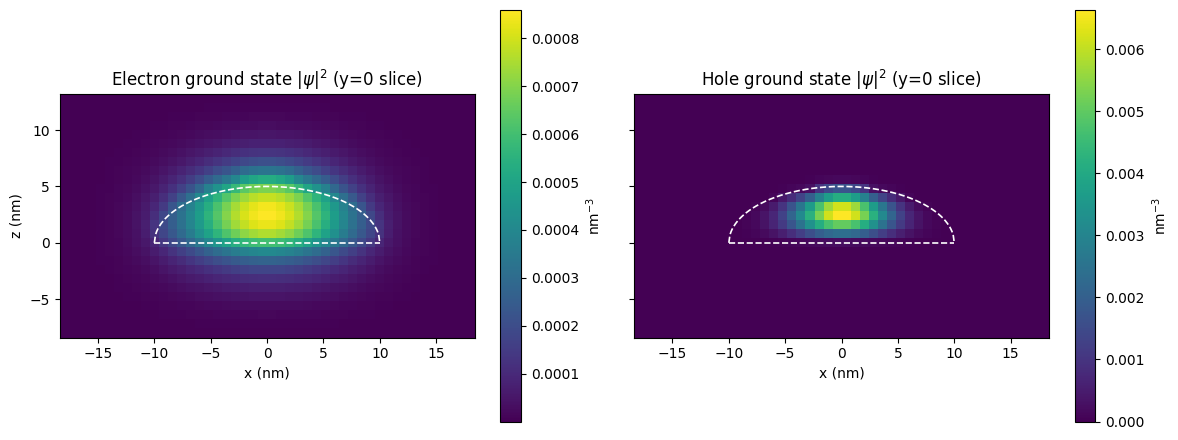

In [13]:
Nx, Ny, Nz = X.shape
mid_y = Ny // 2
dens_e = (psi_e[:, 0]**2).reshape(X.shape)[:, mid_y, :]
dens_h = (psi_h[:, 0]**2).reshape(X.shape)[:, mid_y, :]

# analytic lens outline in the x-z plane: dome z = H*sqrt(1-(x/R)^2) plus the flat base
x_out = np.linspace(-base_radius, base_radius, 200)
z_out = height * np.sqrt(np.clip(1 - (x_out / base_radius)**2, 0, None))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, dens, label in zip(axes, [dens_e, dens_h], ["Electron", "Hole"]):
    im = ax.pcolormesh(cx, cz, dens.T, shading='auto', cmap='viridis')
    ax.plot(x_out, z_out, 'w--', lw=1.2)
    ax.plot([-base_radius, base_radius], [0, 0], 'w--', lw=1.2)
    ax.set_xlabel("x (nm)")
    ax.set_title(f"{label} ground state $|\\psi|^2$ (y=0 slice)")
    ax.set_aspect('equal')
    fig.colorbar(im, ax=ax, label="nm$^{-3}$")
axes[0].set_ylabel("z (nm)")
fig.tight_layout()

## Band-edge line cuts: vertical (through the dome axis) and lateral

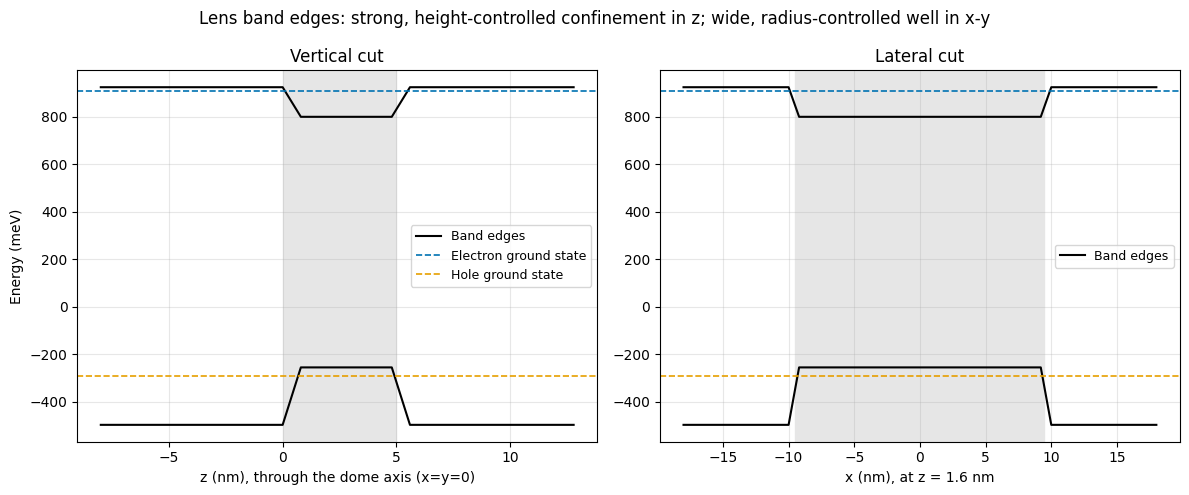

In [14]:
mid_x = Nx // 2
iz_cut = np.argmin(np.abs(cz - height / 3))  # lateral cut at one-third of the dome height

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(cz, V_e[mid_x, mid_y, :] * 1e3, color="black", lw=1.5, label="Band edges")
ax.plot(cz, V_h[mid_x, mid_y, :] * 1e3, color="black", lw=1.5)
ax.axhline(E_e[0] * 1e3, color="#0072B2", ls="--", lw=1.2, label="Electron ground state")
ax.axhline(E_h[0] * 1e3, color="#E69F00", ls="--", lw=1.2, label="Hole ground state")
ax.axvspan(0, height, color="0.9", zorder=0)
ax.set_xlabel("z (nm), through the dome axis (x=y=0)")
ax.set_ylabel("Energy (meV)")
ax.set_title("Vertical cut")
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(cx, V_e[:, mid_y, iz_cut] * 1e3, color="black", lw=1.5, label="Band edges")
ax.plot(cx, V_h[:, mid_y, iz_cut] * 1e3, color="black", lw=1.5)
ax.axhline(E_e[0] * 1e3, color="#0072B2", ls="--", lw=1.2)
ax.axhline(E_h[0] * 1e3, color="#E69F00", ls="--", lw=1.2)
half_width = base_radius * np.sqrt(1 - (cz[iz_cut] / height)**2)
ax.axvspan(-half_width, half_width, color="0.9", zorder=0)
ax.set_xlabel(f"x (nm), at z = {cz[iz_cut]:.1f} nm")
ax.set_title("Lateral cut")
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

fig.suptitle("Lens band edges: strong, height-controlled confinement in z; wide, radius-controlled well in x-y")
fig.tight_layout()

## Notes

- The lens's aspect ratio splits the roles of the two size parameters: `height` mostly sets
  the confinement energies (strong z quantization), while `base_radius` sets the lateral
  level spacing (the $s \to p$ splitting visible as $E_1 - E_0$ in the printed levels).
- To switch material systems, change the two `qd.MATERIALS[...]` lines -- but remember the
  InAs/Sb-family band offsets in `MATERIALS` were calibrated for the type-II broken-gap
  alignment (see the aestimo `database.py` notes), and check electron binding before trusting
  thin-lens results (see the parameter-cell note).
- Next shapes (ellipsoid base already available as `qd.ellipsoid_mask`; pyramid would need a
  new mask) reuse everything here except the mask line.